<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


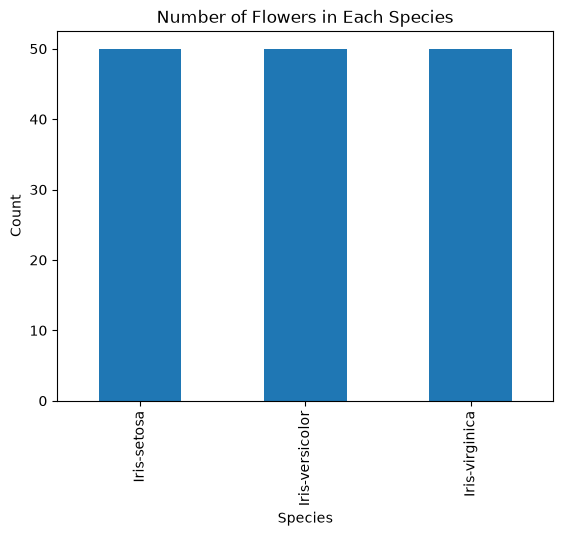

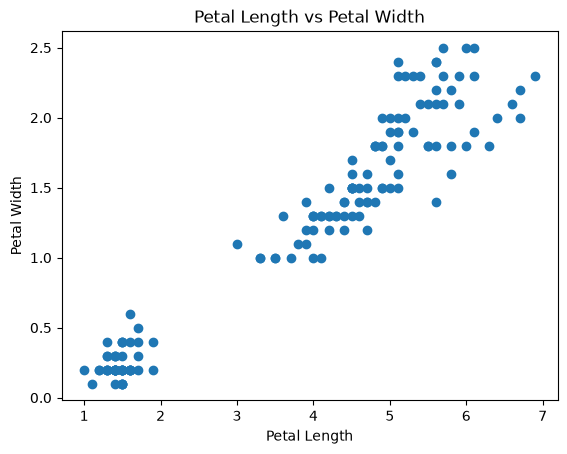

['Iris-versicolor' 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-versicolor']
Model Accuracy : 1.0


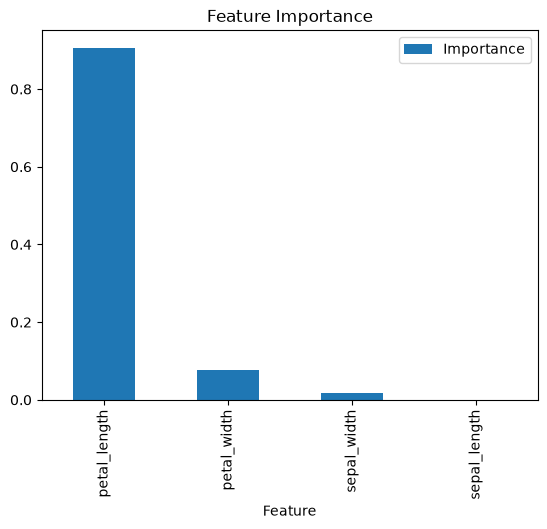

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
iris_data = pd.read_csv("IRIS.csv")

iris_data.head()
iris_data.info()
iris_data.isnull().sum()
iris_data["species"].value_counts()
iris_data["species"].value_counts().plot(
    kind="bar"
)

plt.title("Number of Flowers in Each Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()
plt.scatter(
    iris_data["petal_length"],
    iris_data["petal_width"]
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

plt.show()
input_data = iris_data.drop(
    "species",
    axis=1
)

output_data = iris_data["species"]
x_train, x_test, y_train, y_test = train_test_split(
    input_data,
    output_data,
    test_size=0.2,
    random_state=42
)
iris_model = DecisionTreeClassifier(
    random_state=42
)

iris_model.fit(
    x_train,
    y_train
)
species_prediction = iris_model.predict(
    x_test
)

print(species_prediction[:10])
model_accuracy = accuracy_score(
    y_test,
    species_prediction
)

print("Model Accuracy :", model_accuracy)
feature_importance = pd.DataFrame({
    "Feature": input_data.columns,
    "Importance": iris_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Feature Importance")
plt.show()
